# Project 7: Predictive Modeling

## Objective

Develop machine learning models to predict customer churn using the engineered dataset from Project 6.

The goal is to identify customers who are likely to leave so that the telecom company can take preventive actions to improve customer retention.

# Business Problem

Customer churn is a major challenge for telecom companies.

Acquiring a new customer is often more expensive than retaining an existing one.

By building predictive models, the company can identify customers at risk of leaving and take proactive measures such as personalized offers, discounts, or improved customer support.

This project focuses on developing and comparing multiple machine learning classification models for churn prediction.

# Machine Learning Workflow

1. Import Libraries
2. Load Dataset
3. Prepare Features and Target
4. Split Data into Training and Testing Sets
5. Train Machine Learning Models
6. Compare Model Performance
7. Draw Business Insights

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

%matplotlib inline

In [2]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Data Preparation

Machine learning algorithms require numerical input.

The dataset contains several categorical features, so they must be converted into numerical values before training the models.

In this project, Label Encoding is used to transform categorical variables into numeric form.

In [4]:
label_encoder = LabelEncoder()

for column in df.select_dtypes(include="object").columns:
    df[column] = label_encoder.fit_transform(df[column])

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,5375,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,2,29.85,2505,0
1,3962,1,0,0,0,34,1,0,0,2,...,2,0,0,0,1,0,3,56.95,1466,0
2,2564,1,0,0,0,2,1,0,0,2,...,0,0,0,0,0,1,3,53.85,157,1
3,5535,1,0,0,0,45,0,1,0,2,...,2,2,0,0,1,0,0,42.30,1400,0
4,6511,0,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,2,70.70,925,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   int64  
 1   gender            7043 non-null   int64  
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   int64  
 4   Dependents        7043 non-null   int64  
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   int64  
 7   MultipleLines     7043 non-null   int64  
 8   InternetService   7043 non-null   int64  
 9   OnlineSecurity    7043 non-null   int64  
 10  OnlineBackup      7043 non-null   int64  
 11  DeviceProtection  7043 non-null   int64  
 12  TechSupport       7043 non-null   int64  
 13  StreamingTV       7043 non-null   int64  
 14  StreamingMovies   7043 non-null   int64  
 15  Contract          7043 non-null   int64  
 16  PaperlessBilling  7043 non-null   int64  


# Features and Target Variable

Before training a machine learning model, we separate the dataset into:

- **Features (X):** Input variables used to make predictions.
- **Target (y):** Output variable that the model learns to predict.

In this project:

- Features = All columns except **Churn**
- Target = **Churn**

In [7]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [8]:
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (7043, 20)
Shape of y: (7043,)


# Train-Test Split

The dataset is divided into training and testing sets.

- Training Set (80%): Used to train the model.
- Testing Set (20%): Used to evaluate the model on unseen data.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [11]:
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Target  :", y_train.shape)
print("Testing Target   :", y_test.shape)

Training Features: (5634, 20)
Testing Features : (1409, 20)
Training Target  : (5634,)
Testing Target   : (1409,)


# Logistic Regression

Logistic Regression is a supervised machine learning algorithm used for binary classification problems.

In this project, it is used to predict whether a customer is likely to churn based on customer information.

In [12]:
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [13]:
y_pred = logistic_model.predict(X_test)

In [14]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8148


In [15]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[940  96]
 [165 208]]


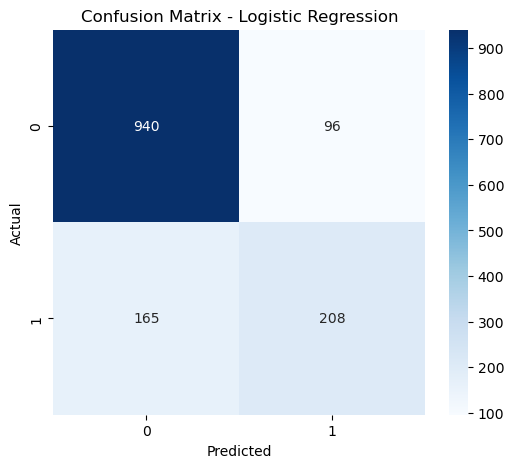

In [16]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [17]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1036
           1       0.68      0.56      0.61       373

    accuracy                           0.81      1409
   macro avg       0.77      0.73      0.75      1409
weighted avg       0.81      0.81      0.81      1409



# Logistic Regression Results

## Model Performance

- Accuracy: **81.48%**

### Business Interpretation

The Logistic Regression model correctly classified approximately 81% of customers.

It successfully identified many customers who were likely to stay and correctly predicted 208 customers who were at risk of churning.

However, the model failed to identify 165 customers who actually churned. Improving the identification of these customers could help the company implement more effective retention strategies.

This model serves as a strong baseline for comparison with other machine learning algorithms.

# K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) is a supervised machine learning algorithm used for classification and regression.

For classification, it predicts the class of a new observation by looking at the most similar observations in the training data.

In [18]:
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

In [19]:
knn_model.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [20]:
y_pred_knn = knn_model.predict(X_test)

In [21]:
accuracy_knn = accuracy_score(
    y_test,
    y_pred_knn
)

print(f"Accuracy: {accuracy_knn:.4f}")

Accuracy: 0.7729


In [22]:
cm_knn = confusion_matrix(
    y_test,
    y_pred_knn
)

print(cm_knn)

[[899 137]
 [183 190]]


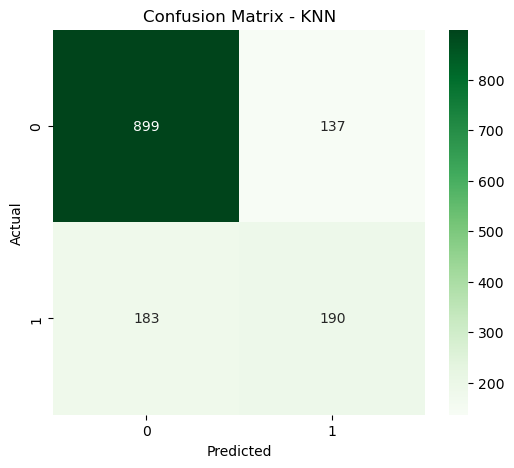

In [23]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [24]:
print(
    classification_report(
        y_test,
        y_pred_knn
    )
)

              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1036
           1       0.58      0.51      0.54       373

    accuracy                           0.77      1409
   macro avg       0.71      0.69      0.70      1409
weighted avg       0.76      0.77      0.77      1409



# Comparison: Logistic Regression vs K-Nearest Neighbors (KNN)

The first two machine learning models are compared to evaluate their performance in predicting customer churn.

In [25]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "K-Nearest Neighbors"],
    "Accuracy": [accuracy, accuracy_knn]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.814762
1,K-Nearest Neighbors,0.772889


In [28]:
comparison.to_csv(
    "../outputs/model_comparison.csv",
    index=False
)

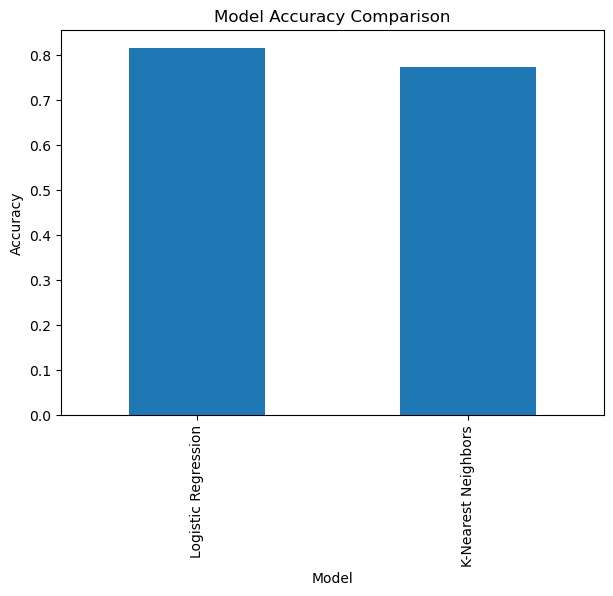

In [26]:
comparison.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    figsize=(7,5),
    legend=False
)

plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.show()

# Comparison Results

| Metric | Logistic Regression | K-Nearest Neighbors |
|--------|--------------------:|--------------------:|
| Accuracy | **81.48%** | **77.29%** |
| Precision (Churn) | **0.68** | **0.58** |
| Recall (Churn) | **0.56** | **0.51** |
| F1-Score (Churn) | **0.61** | **0.54** |

## Interpretation

- Logistic Regression achieved higher overall accuracy than KNN.
- Logistic Regression identified churning customers more effectively.
- KNN produced more false predictions compared to Logistic Regression.
- Logistic Regression is the better-performing model for this dataset based on the current evaluation metrics.

# Business Insights

The predictive models were developed to identify customers who are likely to leave the telecom company.

## Key Findings

- Logistic Regression achieved an accuracy of **81.48%**, outperforming K-Nearest Neighbors.
- Logistic Regression identified customer churn more effectively than KNN.
- KNN produced lower recall for churn prediction, indicating that it missed more customers who actually churned.

## Business Value

A telecom company can use these predictions to:

- Contact customers who are likely to churn.
- Offer personalized discounts.
- Improve customer support.
- Increase customer retention.
- Reduce revenue loss.

# Conclusion

In this project, two supervised machine learning algorithms were implemented for customer churn prediction.

## Models Evaluated

- Logistic Regression
- K-Nearest Neighbors (KNN)

Among the evaluated models, Logistic Regression achieved the best overall performance on the Telco Customer Churn dataset.

This project introduced the complete predictive modeling workflow, including data preparation, train-test splitting, feature scaling, model training, prediction, and evaluation.